In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
dfd = pd.read_csv("day.csv")
dfh = pd.read_csv("hour.csv")

In [45]:
print(dfd.head())
print(dfh.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

In [46]:
dfd = dfd.drop(columns=["dteday"])
dfh = dfh.drop(columns=["dteday"])

In [47]:
dfd = dfd.select_dtypes(include=[np.number])
dfh = dfh.select_dtypes(include=[np.number])

In [48]:
def evaluate_models(df, label="Dataset"):

    X = df.drop("cnt", axis=1)
    y = df["cnt"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42)
    }

    results = []
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        predictions[name] = pred

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)

        results.append([name, rmse, mae, r2])

    df_results = pd.DataFrame(
        results, columns=["Model", "RMSE", "MAE", "R2"]
    )

    print(f"\n===== Performance on {label} =====")
    print(df_results)

    return df_results, y_test, predictions


===== Performance on Day Dataset =====
               Model          RMSE           MAE        R2
0  Linear Regression  8.616079e-13  6.574212e-13  1.000000
1      Random Forest  1.019673e+02  6.544476e+01  0.997407
2  Gradient Boosting  1.034349e+02  7.306240e+01  0.997332


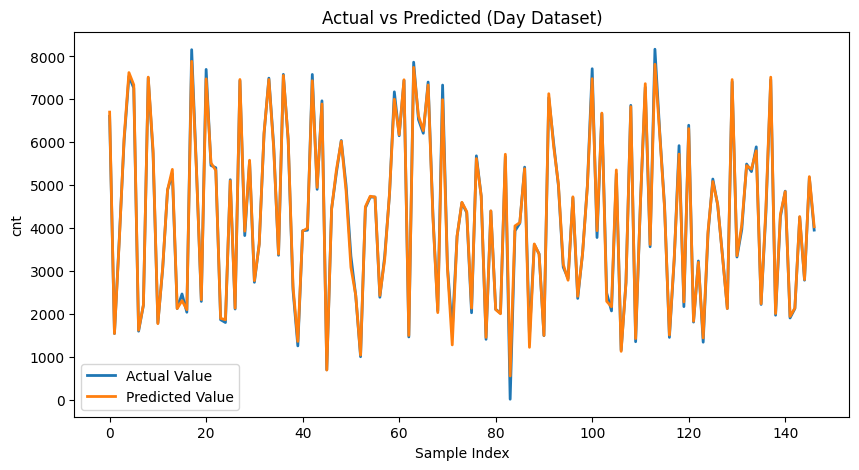

   Actual (y_test)  Predicted (RF)
0             6606        6703.725
1             1550        1550.740
2             3747        3706.845
3             6041        6103.635
4             7538        7623.485


In [49]:
results_day_df, y_day_test, preds_day = evaluate_models(dfd, "Day Dataset")

day_best_pred = preds_day["Random Forest"]

plt.figure(figsize=(10, 5))
plt.plot(y_day_test.values, label="Actual Value", linewidth=2)
plt.plot(day_best_pred, label="Predicted Value", linewidth=2)
plt.title("Actual vs Predicted (Day Dataset)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()

comparison_day = pd.DataFrame({
    "Actual (y_test)": y_day_test.values[:5],
    "Predicted (RF)": day_best_pred[:5]
})
print(comparison_day)


===== Performance on Hour Dataset =====
               Model          RMSE           MAE        R2
0  Linear Regression  2.862396e-11  2.469898e-11  1.000000
1      Random Forest  2.744431e+00  9.386306e-01  0.999762
2  Gradient Boosting  5.235476e+00  3.303406e+00  0.999134


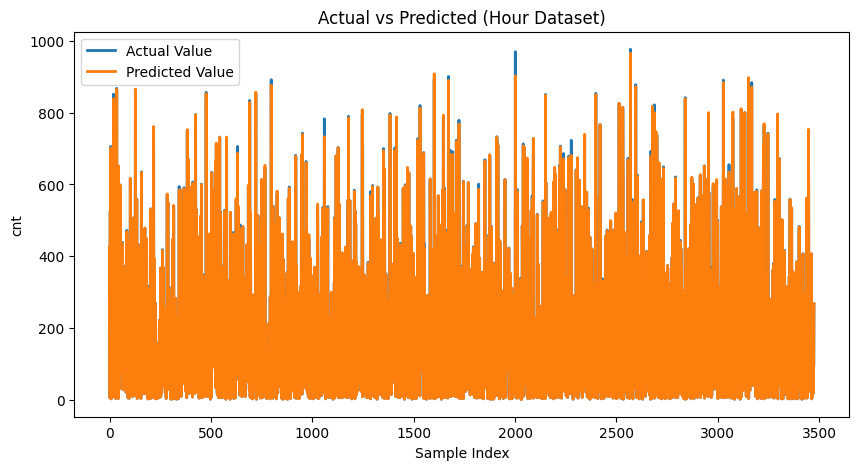

   Actual (y_test)  Predicted (RF)
0              425         425.670
1               88          87.395
2                4           4.000
3              526         525.550
4               13          13.170


In [50]:
results_hour_df, y_hour_test, preds_hour = evaluate_models(dfh, "Hour Dataset")

hour_best_pred = preds_hour["Random Forest"]

plt.figure(figsize=(10, 5))
plt.plot(y_hour_test.values, label="Actual Value", linewidth=2)
plt.plot(hour_best_pred, label="Predicted Value", linewidth=2)
plt.title("Actual vs Predicted (Hour Dataset)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()

comparison_hour = pd.DataFrame({
    "Actual (y_test)": y_hour_test.values[:5],
    "Predicted (RF)": hour_best_pred[:5]
})
print(comparison_hour)

In [51]:
comparison_df = pd.DataFrame({
    "Actual (y_test)": y_hour_test.values[:5],
    "Predicted (RF)": hour_best_pred[:5]
})

print(comparison_df)


   Actual (y_test)  Predicted (RF)
0              425         425.670
1               88          87.395
2                4           4.000
3              526         525.550
4               13          13.170


In [52]:
def plot_feature_importance(df, dataset_name="Dataset", target_col="cnt"):
    """
    Trains a basic RandomForestRegressor and plots feature importance.
    """

    X = df.drop(target_col, axis=1)
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)

    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=feat_imp, x="Importance", y="Feature")
    plt.title(f"Feature Importance ({dataset_name})")
    plt.show()


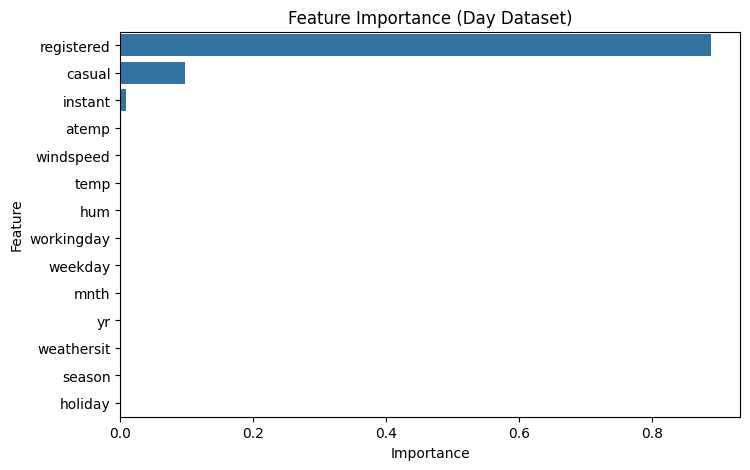

In [53]:
plot_feature_importance(dfd, dataset_name="Day Dataset")

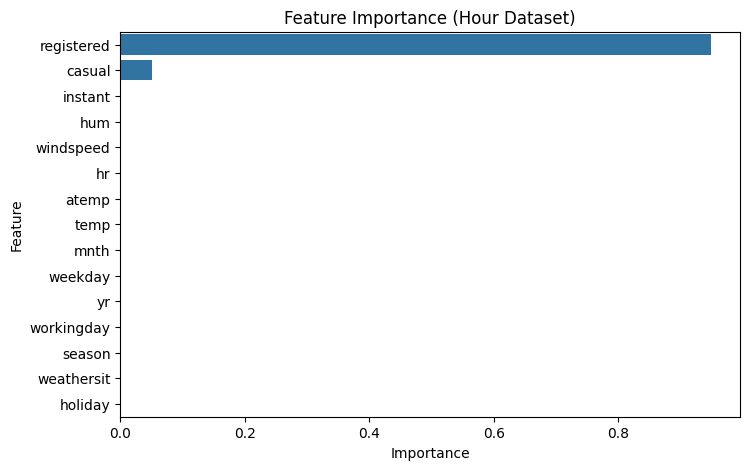

In [54]:
plot_feature_importance(dfh, dataset_name="Hour Dataset")

In [55]:
comparison_df = pd.DataFrame({
    "Dataset": ["Day", "Hour"],
    "Best Model": [
        results_day_df.loc[results_day_df["RMSE"].idxmin(), "Model"],
        results_hour_df.loc[results_hour_df["RMSE"].idxmin(), "Model"]
    ],
    "Best RMSE": [
        results_day_df["RMSE"].min(),
        results_hour_df["RMSE"].min()
    ]
})

print("== Dataset Comparison ===")
print(comparison_df)

== Dataset Comparison ===
  Dataset         Best Model     Best RMSE
0     Day  Linear Regression  8.616079e-13
1    Hour  Linear Regression  2.862396e-11
